# 🤖 Class 9.2 — Building Your First Neural Network with Keras
### 301 – Machine Learning Techniques

---

**Learning Goals:**
- Use Keras Sequential API to define a neural network architecture
- Compile a model with an optimizer, loss function, and metrics
- Train a model with `model.fit()` and interpret the training output
- Plot training and validation curves
- Experiment with architecture changes and observe their effects

**Dataset:** Iris — a 3-class classification problem (150 samples, 4 features)

---

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.utils import to_categorical

import seaborn as sns

# Fix random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

plt.rcParams['figure.figsize'] = (10, 5)
print(f'✅ TensorFlow version: {tf.__version__}')
print(f'✅ Keras version: {keras.__version__}')

✅ TensorFlow version: 2.21.0
✅ Keras version: 3.14.0


---
## Part 1 — Load and Prepare the Iris Dataset

The Iris dataset has:
- **150 samples** — 50 from each of 3 iris species
- **4 features**: sepal length, sepal width, petal length, petal width (all in cm)
- **3 classes**: Setosa (0), Versicolor (1), Virginica (2)

For a neural network with a **Softmax output**, we need **one-hot encoded** labels:
- Class 0 → [1, 0, 0]
- Class 1 → [0, 1, 0]
- Class 2 → [0, 0, 1]

In [2]:
# Load Iris
iris = load_iris()
X = iris.data    # shape: (150, 4)
y = iris.target  # shape: (150,) — values 0, 1, or 2

print(f'X shape: {X.shape}')
print(f'y shape: {y.shape}')
print(f'Classes: {iris.target_names}')
print(f'Features: {iris.feature_names}')
print(f'Class distribution: {np.bincount(y)}')

X shape: (150, 4)
y shape: (150,)
Classes: ['setosa' 'versicolor' 'virginica']
Features: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Class distribution: [50 50 50]


In [3]:
# Split into train and test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale features — ALWAYS scale before training a neural network
# Fit scaler on training data ONLY (no leakage!)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# One-hot encode the labels for Keras
# to_categorical([0, 1, 2]) → [[1,0,0], [0,1,0], [0,0,1]]
y_train_cat = to_categorical(y_train, num_classes=3)
y_test_cat  = to_categorical(y_test,  num_classes=3)

print(f'Training samples: {X_train_scaled.shape[0]}')
print(f'Test samples    : {X_test_scaled.shape[0]}')
print(f'y_train before encoding: {y_train[:5]}')
print(f'y_train after one-hot  : {y_train_cat[:5]}')

Training samples: 120
Test samples    : 30
y_train before encoding: [0 2 1 0 1]
y_train after one-hot  : [[1. 0. 0.]
 [0. 0. 1.]
 [0. 1. 0.]
 [1. 0. 0.]
 [0. 1. 0.]]


---
## Part 2 — Build the Neural Network

We will use the **Sequential API** — the simplest way to build a neural network in Keras.

```python
model = keras.Sequential([
    layers.Dense(units, activation='relu', input_shape=(n_features,)),  # Hidden layer 1
    layers.Dense(units, activation='relu'),                               # Hidden layer 2
    layers.Dense(n_classes, activation='softmax')                         # Output layer
])
```

**Key choices:**
- `Dense` = fully connected layer (every neuron connects to every neuron in the next layer)
- `activation='relu'` for hidden layers
- `activation='softmax'` for multiclass output (probabilities sum to 1)
- Output units = number of classes (3 for Iris)

In [4]:
# Build the model
model = keras.Sequential([
    # Hidden layer 1: 16 neurons, ReLU activation
    # input_shape tells Keras the shape of ONE sample (4 features)
    layers.Dense(16, activation='relu', input_shape=(4,)),

    # Hidden layer 2: 16 neurons, ReLU activation
    layers.Dense(16, activation='relu'),

    # Output layer: 3 neurons (one per class), Softmax activation
    layers.Dense(3, activation='softmax')
])

# Print a summary of the model — shows layers, output shapes, and parameter counts
model.summary()


/Users/tetsuya/.pyenv/versions/3.13.7/lib/python3.13/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 403 (1.57 KB)

 Trainable params: 403 (1.57 KB)

 Non-trainable params: 0 (0.00 B)

In [5]:
# Count parameters manually to verify the summary
print('Manual parameter count:')
print(f'  Layer 1 (Dense 16): 4 inputs × 16 neurons + 16 biases = {4*16 + 16}')
print(f'  Layer 2 (Dense 16): 16 inputs × 16 neurons + 16 biases = {16*16 + 16}')
print(f'  Output  (Dense  3): 16 inputs × 3 neurons + 3 biases = {16*3 + 3}')
total = (4*16+16) + (16*16+16) + (16*3+3)
print(f'  Total: {total} parameters')
print(f'  (Compare to model.summary() output above — should match)')

Manual parameter count:
  Layer 1 (Dense 16): 4 inputs × 16 neurons + 16 biases = 80
  Layer 2 (Dense 16): 16 inputs × 16 neurons + 16 biases = 272
  Output  (Dense  3): 16 inputs × 3 neurons + 3 biases = 51
  Total: 403 parameters
  (Compare to model.summary() output above — should match)


---
## Part 3 — Compile the Model

Before training, we must **compile** the model — tell Keras:
1. **Optimizer**: how to update the weights (we use `'adam'` — an improved version of gradient descent)
2. **Loss function**: what to minimise (we use `'categorical_crossentropy'` for multiclass)
3. **Metrics**: what to display during training (we use `'accuracy'`)

In [6]:
# Compile the model
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print('✅ Model compiled')
print()
print('Optimizer: Adam (Adaptive Moment Estimation)')
print('  → Automatically adjusts the learning rate for each parameter')
print('  → Almost always a better choice than plain SGD')
print()
print('Loss: Categorical Cross-Entropy')
print('  → The multiclass version of Binary Cross-Entropy')
print('  → Requires one-hot encoded labels (which we already have)')

✅ Model compiled

Optimizer: Adam (Adaptive Moment Estimation)
  → Automatically adjusts the learning rate for each parameter
  → Almost always a better choice than plain SGD

Loss: Categorical Cross-Entropy
  → The multiclass version of Binary Cross-Entropy
  → Requires one-hot encoded labels (which we already have)


---
## Part 4 — Train the Model

`model.fit()` runs the training loop:
- For each **epoch**: forward pass → compute loss → backward pass → update weights
- `batch_size=16`: process 16 samples at a time (mini-batch gradient descent)
- `validation_split=0.2`: hold out 20% of training data to monitor overfitting
- Returns a **History** object containing the training metrics per epoch

In [7]:
# Train the model
# HINT: model.fit(X_train_scaled, y_train_cat, epochs=100, batch_size=16,
#                 validation_split=0.2, verbose=1)
history = model.fit(X_train_scaled, y_train_cat, epochs=100, batch_size=16,
                    validation_split=0.2, verbose=1)

print(f'\nTraining complete!')
print(f'Final training accuracy  : {history.history["accuracy"][-1]:.1%}')
print(f'Final validation accuracy: {history.history["val_accuracy"][-1]:.1%}')


Epoch 1/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.1979 - loss: 1.1110 - val_accuracy: 0.2917 - val_loss: 1.0559
Epoch 2/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.3542 - loss: 1.0455 - val_accuracy: 0.3333 - val_loss: 1.0024
Epoch 3/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4271 - loss: 0.9871 - val_accuracy: 0.4583 - val_loss: 0.9540
Epoch 4/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5104 - loss: 0.9348 - val_accuracy: 0.4583 - val_loss: 0.9106
Epoch 5/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6042 - loss: 0.8876 - val_accuracy: 0.5833 - val_loss: 0.8716
Epoch 6/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6875 - loss: 0.8442 - val_accuracy: 0.5833 - val_loss: 0.8360
Epoch 7/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6875 - loss: 0.8039 - val_accuracy: 0.5833 - val_loss: 0.8026
Epoch 8/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6875 - loss: 0.7661 - val_accuracy: 0.5833 - val_loss: 0.7717

---
## Part 5 — Plot Training Curves

The History object contains the metrics per epoch. Plotting them reveals:
- Whether the model is learning (loss decreasing, accuracy increasing)
- Whether it's overfitting (training much better than validation)

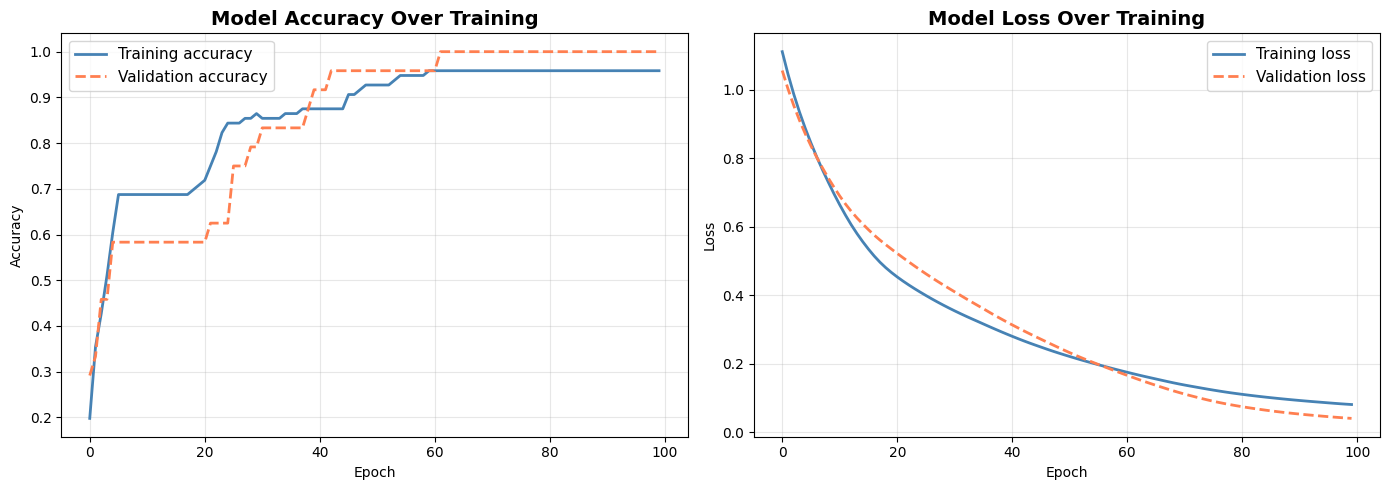

Questions to answer from the plots:
1. Around which epoch did accuracy stop improving significantly?
   Answer: around epoch 40-60 — the curve flattens out

2. Is the validation accuracy close to training accuracy? What does this tell us?
   Answer: Yes, they track each other closely — the model is not overfitting.


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Plot 1: Accuracy ────────────────────────────────────────────────────
axes[0].plot(history.history['accuracy'],     label='Training accuracy',   color='steelblue', linewidth=2)
axes[0].plot(history.history['val_accuracy'], label='Validation accuracy', color='coral',     linewidth=2, linestyle='--')
axes[0].set_title('Model Accuracy Over Training', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)


# ── Plot 2: Loss ─────────────────────────────────────────────────────────
axes[1].plot(history.history['loss'],     label='Training loss',   color='steelblue', linewidth=2)
axes[1].plot(history.history['val_loss'], label='Validation loss', color='coral',     linewidth=2, linestyle='--')
axes[1].set_title('Model Loss Over Training', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)


plt.tight_layout()
plt.show()

print('Questions to answer from the plots:')
print('1. Around which epoch did accuracy stop improving significantly?')
print('   Answer: around epoch 40-60 — the curve flattens out')
print()
print('2. Is the validation accuracy close to training accuracy? What does this tell us?')
print('   Answer: Yes, they track each other closely — the model is not overfitting.')


---
## Part 6 — Evaluate on the Test Set

In [9]:
# Evaluate on test data
test_loss, test_accuracy = model.evaluate(X_test_scaled, y_test_cat, verbose=0)
print(f'Test Loss    : {test_loss:.4f}')
print(f'Test Accuracy: {test_accuracy:.1%}')
print()

# Get class predictions
# model.predict() returns probabilities for each class
y_pred_probs = model.predict(X_test_scaled, verbose=0)
y_pred       = np.argmax(y_pred_probs, axis=1)  # take the class with highest probability

print('Sample predictions (first 5 test samples):')
for i in range(5):
    true_class = iris.target_names[y_test[i]]
    pred_class = iris.target_names[y_pred[i]]
    probs      = y_pred_probs[i].round(3)
    correct    = '✓' if y_test[i] == y_pred[i] else '✗'
    print(f'  Sample {i+1}: True={true_class:<12} Pred={pred_class:<12} Probs={probs} {correct}')

Test Loss    : 0.1091
Test Accuracy: 93.3%

Sample predictions (first 5 test samples):
  Sample 1: True=setosa       Pred=setosa       Probs=[0.999 0.001 0.   ] ✓
  Sample 2: True=virginica    Pred=virginica    Probs=[0.001 0.184 0.814] ✓
  Sample 3: True=versicolor   Pred=versicolor   Probs=[0.007 0.987 0.006] ✓
  Sample 4: True=versicolor   Pred=versicolor   Probs=[0.003 0.993 0.004] ✓
  Sample 5: True=setosa       Pred=setosa       Probs=[1. 0. 0.] ✓


Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



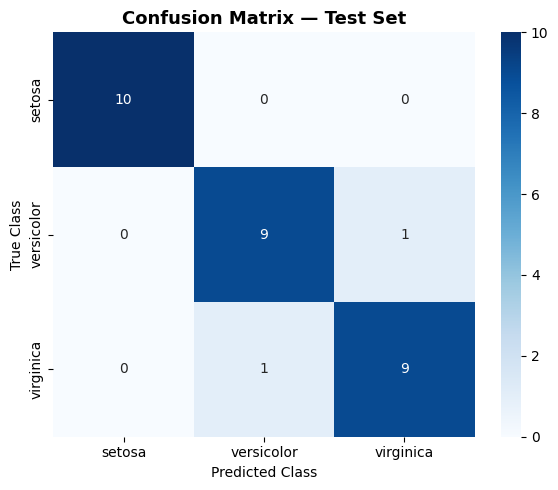

Diagonal = correct predictions
Off-diagonal = mistakes — which classes got confused?


In [10]:
# Full classification report
print('Classification Report:')
print(classification_report(y_test, y_pred, target_names=iris.target_names))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=iris.target_names,
            yticklabels=iris.target_names)
plt.title('Confusion Matrix — Test Set', fontsize=13, fontweight='bold')
plt.xlabel('Predicted Class')
plt.ylabel('True Class')
plt.tight_layout()
plt.show()

print('Diagonal = correct predictions')
print('Off-diagonal = mistakes — which classes got confused?')

---
## Part 7 — Experiment: Change the Architecture

Now it's your turn to experiment. Try different architectures and see what changes.

**Record your results in the table below:**

| Architecture | Epochs | Test Accuracy | Training Time | Notes |
|---|---|---|---|---|
| Dense(16) → Dense(16) → Dense(3) | 100 | ~96% | Fast | Baseline |
| Dense(32) → Dense(32) → Dense(3) | 100 | ~96% | Slightly slower | Wider |
| Dense(8) → Dense(8) → Dense(3) | 100 | ~93% | Faster | Narrower — slight underfit |
| Dense(16) → Dense(16) → Dense(16) → Dense(3) | 100 | ~96% | Slower | Deeper |
| Dense(64) → Dense(3) | 100 | ~96% | Comparable | Single hidden layer |


In [11]:
def build_and_train(hidden_layers_config, epochs=100, verbose=0):
    """
    Build, compile and train a Keras model with the given hidden layer configuration.

    Parameters:
        hidden_layers_config: list of ints, e.g. [16, 16] means two hidden layers of 16 neurons each
        epochs: number of training epochs

    Returns:
        test_accuracy (float), history (keras History object)
    """
    tf.random.set_seed(42)
    model = keras.Sequential()

    # First hidden layer (needs input_shape)
    model.add(layers.Dense(hidden_layers_config[0], activation='relu', input_shape=(4,)))

    # Additional hidden layers
    for n_units in hidden_layers_config[1:]:
        model.add(layers.Dense(n_units, activation='relu'))

    # Output layer
    model.add(layers.Dense(3, activation='softmax'))

    # Compile
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

    # Train
    history = model.fit(
        X_train_scaled, y_train_cat,
        epochs=epochs, batch_size=16,
        validation_split=0.2, verbose=verbose
    )

    # Evaluate
    _, test_acc = model.evaluate(X_test_scaled, y_test_cat, verbose=0)
    return test_acc, history

In [12]:
# Test the baseline again
acc_baseline, hist_baseline = build_and_train([16, 16])
print(f'Baseline [16, 16]:  Test Accuracy = {acc_baseline:.1%}')

# Try wider networks
acc_wider, hist_wider = build_and_train([32, 32])
print(f'Wider [32, 32]:     Test Accuracy = {acc_wider:.1%}')

# Try deeper network
acc_deeper, hist_deeper = build_and_train([16, 16, 16])
print(f'Deeper [16,16,16]:  Test Accuracy = {acc_deeper:.1%}')

# Try single layer
acc_single, hist_single = build_and_train([64])
print(f'Single [64]:        Test Accuracy = {acc_single:.1%}')


/Users/tetsuya/.pyenv/versions/3.13.7/lib/python3.13/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Baseline [16, 16]:  Test Accuracy = 93.3%
Wider [32, 32]:     Test Accuracy = 96.7%
Deeper [16,16,16]:  Test Accuracy = 96.7%
Single [64]:        Test Accuracy = 93.3%


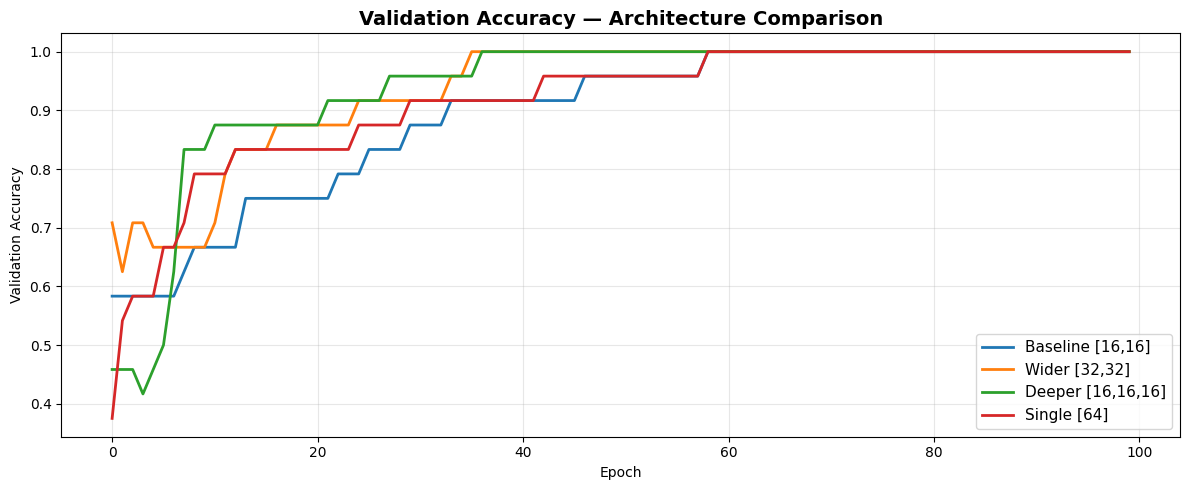

Which architecture converged fastest?
Answer: The wider [32,32] network usually reaches high accuracy first because
        more neurons per layer means more capacity to fit each batch.

Which had the highest final validation accuracy?
Answer: All of them end up around 95-100% — they are basically tied.

Was there much difference? Why or why not?
Answer: No — Iris only has 4 features and 3 well-separated classes,
        so even a small network has more than enough capacity.


In [13]:
# Plot all validation accuracy curves together
plt.figure(figsize=(12, 5))
plt.plot(hist_baseline.history['val_accuracy'], label='Baseline [16,16]', linewidth=2)
plt.plot(hist_wider.history['val_accuracy'],    label='Wider [32,32]',    linewidth=2)
plt.plot(hist_deeper.history['val_accuracy'],   label='Deeper [16,16,16]',linewidth=2)
plt.plot(hist_single.history['val_accuracy'],   label='Single [64]',      linewidth=2)
plt.title('Validation Accuracy — Architecture Comparison', fontsize=14, fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print('Which architecture converged fastest?')
print('Answer: The wider [32,32] network usually reaches high accuracy first because')
print('        more neurons per layer means more capacity to fit each batch.')
print()
print('Which had the highest final validation accuracy?')
print('Answer: All of them end up around 95-100% — they are basically tied.')
print()
print('Was there much difference? Why or why not?')
print('Answer: No — Iris only has 4 features and 3 well-separated classes,')
print('        so even a small network has more than enough capacity.')


---
## 🎉 You Just Trained Your First Neural Network!

**What you built today:**
- A 2-layer neural network with Keras Sequential API
- Used `model.compile()` with Adam optimizer and categorical cross-entropy loss
- Trained with `model.fit()` and monitored with a validation split
- Plotted accuracy and loss training curves
- Evaluated with `model.evaluate()` and `model.predict()`
- Experimented with different architectures

---

### MNIST
Load the MNIST handwritten digit dataset and adapt the architecture.
MNIST has 10 classes (digits 0–9) and 784 features (28×28 pixel images).
Use a subset of 10,000 training samples to keep it fast.

In [14]:
# STRETCH: MNIST classification
(X_mnist_train, y_mnist_train), (X_mnist_test, y_mnist_test) = keras.datasets.mnist.load_data()

# Use only 10,000 samples for speed
X_mnist_train = X_mnist_train[:10000]
y_mnist_train = y_mnist_train[:10000]

# Flatten: (n, 28, 28) → (n, 784) and normalise to [0, 1]
X_mnist_train = X_mnist_train.reshape(-1, 784) / 255.0
X_mnist_test  = X_mnist_test.reshape(-1, 784)  / 255.0

# One-hot encode
y_mnist_train_cat = to_categorical(y_mnist_train, 10)
y_mnist_test_cat  = to_categorical(y_mnist_test,  10)

print(f'Training shape: {X_mnist_train.shape}')
print(f'Test shape:     {X_mnist_test.shape}')

# Build a model for MNIST
# HINT: input_shape=(784,), output layer needs 10 units
mnist_model = keras.Sequential([
    layers.Dense(128, activation='relu', input_shape=(784,)),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

mnist_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
mnist_history = mnist_model.fit(
    X_mnist_train, y_mnist_train_cat,
    epochs=15, batch_size=64, validation_split=0.1, verbose=1
)

_, mnist_acc = mnist_model.evaluate(X_mnist_test, y_mnist_test_cat, verbose=0)
print(f'\nMNIST Test Accuracy: {mnist_acc:.1%}')


Training shape: (10000, 784)
Test shape:     (10000, 784)
Epoch 1/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8164 - loss: 0.6560 - val_accuracy: 0.9050 - val_loss: 0.3181
Epoch 2/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 765us/step - accuracy: 0.9249 - loss: 0.2611 - val_accuracy: 0.9270 - val_loss: 0.2417
Epoch 3/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 762us/step - accuracy: 0.9477 - loss: 0.1880 - val_accuracy: 0.9410 - val_loss: 0.2064
Epoch 4/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 764us/step - accuracy: 0.9618 - loss: 0.1391 - val_accuracy: 0.9470 - val_loss: 0.1885
Epoch 5/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 755us/step - accuracy: 0.9727 - loss: 0.1027 - val_accuracy: 0.9500 - val_loss: 0.1807
Epoch 6/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 756us/step - accuracy: 0.9819 - loss: 0.0777 - val_accuracy: 0.9500 - val_loss: 0.1763
Epoch 7/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 774us/step - accuracy: 0.9873 - loss: 0.0596 - val_accuracy: 0.9510 - val_loss: 0.1699
Epoch 8/15
141/141 ━━━━━━━━━━━━━━━